In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import joblib

In [ ]:
model = joblib.load("../models/logistic_regression_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1409, 30)
y_test shape: (1409,)


In [ ]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Model Evaluation")
print("================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Model Evaluation
Accuracy:  0.8062
Precision: 0.6593
Recall:    0.5588
F1-Score:  0.6049
ROC-AUC:   0.8422


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[927 108]
 [165 209]]


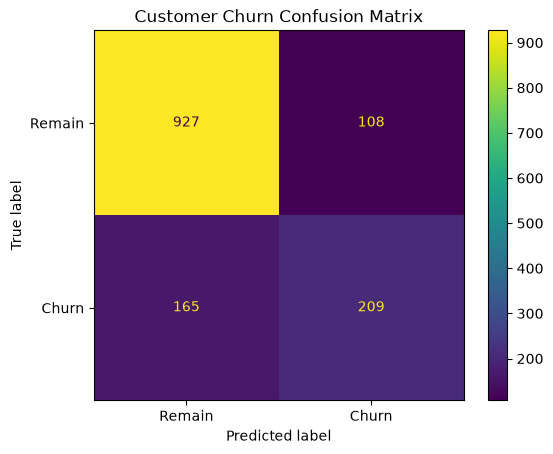

In [ ]:
# ==========================================
# Visualize Confusion Matrix
# ==========================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Remain", "Churn"]
)

disp.plot()

plt.title("Customer Churn Confusion Matrix")
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[927 108]
 [165 209]]


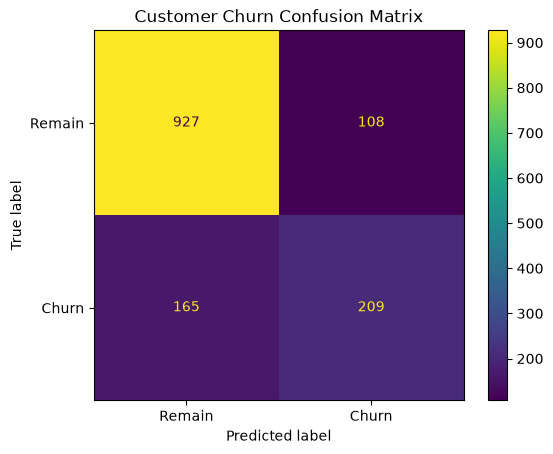

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Remain", "Churn"]
)

disp.plot()

plt.title("Customer Churn Confusion Matrix")
plt.show()

In [ ]:
model.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

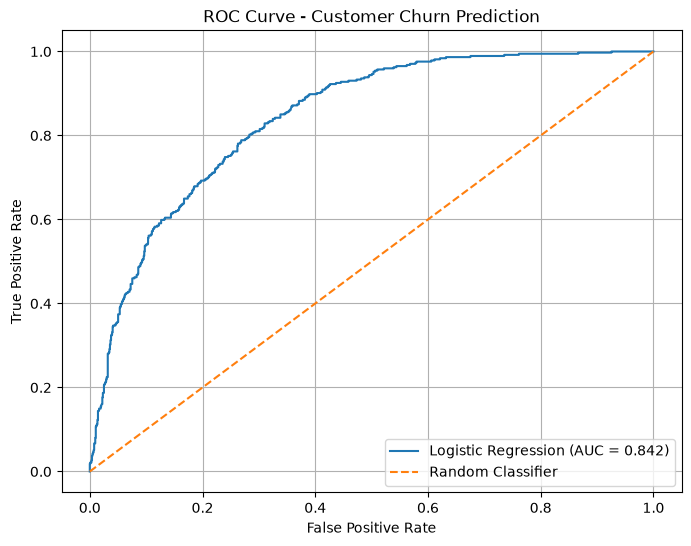

In [ ]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Customer Churn Prediction")

plt.legend()

plt.grid()

plt.show()

In [ ]:
# ==========================================
# Threshold Analysis
# ==========================================

thresholds_to_test = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds_to_test:

    y_threshold_pred = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Customers Flagged": y_threshold_pred.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-Score,Customers Flagged
0,0.20,0.467153,0.855615,0.604344,685
1,0.25,0.498355,0.810160,0.617108,608
2,0.30,0.519337,0.754011,0.615049,543
3,0.35,0.544330,0.705882,0.614668,485
4,0.40,0.569476,0.668449,0.615006,439
5,0.45,0.600522,0.614973,0.607662,383
6,0.50,0.659306,0.558824,0.604920,317
7,0.55,0.678431,0.462567,0.550079,255
8,0.60,0.717703,0.401070,0.514580,209


In [ ]:
# ==========================================
# Best Threshold Based on F1-Score
# ==========================================

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

print("Best threshold based on F1-score:")
print(best_threshold_row)

Best threshold based on F1-score:
Threshold              0.250000
Precision              0.498355
Recall                 0.810160
F1-Score               0.617108
Customers Flagged    608.000000
Name: 1, dtype: float64


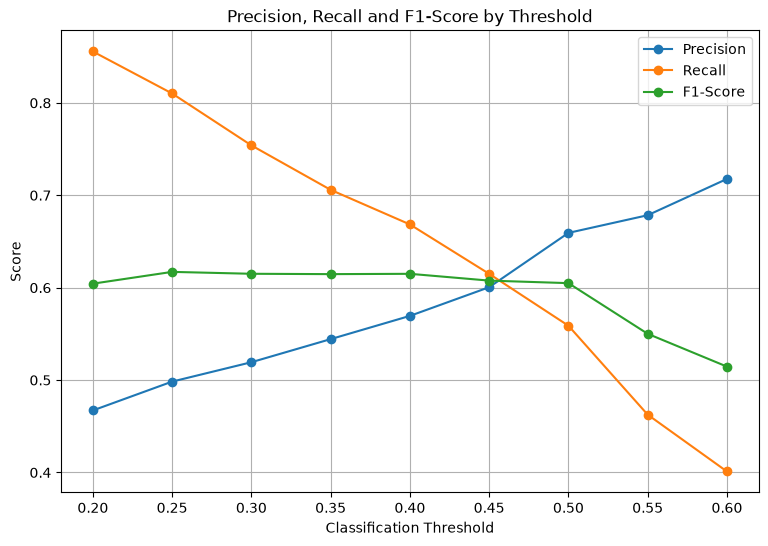

In [ ]:
# ==========================================
# Threshold Performance Visualization
# ==========================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title("Precision, Recall and F1-Score by Threshold")

plt.legend()

plt.grid()

plt.show()

In [ ]:
# ==========================================
# Compare Confusion Matrices
# ==========================================

comparison_thresholds = [0.25, 0.40, 0.50]

for threshold in comparison_thresholds:

    y_threshold_pred = (
        y_probability >= threshold
    ).astype(int)

    cm_threshold = confusion_matrix(
        y_test,
        y_threshold_pred
    )

    print("=" * 50)
    print(f"Threshold: {threshold:.0%}")
    print("=" * 50)

    print(cm_threshold)

    print(
        f"Precision: {precision_score(y_test, y_threshold_pred):.2%}"
    )

    print(
        f"Recall: {recall_score(y_test, y_threshold_pred):.2%}"
    )

    print(
        f"F1-Score: {f1_score(y_test, y_threshold_pred):.2%}"
    )

    print(
        f"Customers Flagged: {y_threshold_pred.sum()}"
    )

Threshold: 25%
[[730 305]
 [ 71 303]]
Precision: 49.84%
Recall: 81.02%
F1-Score: 61.71%
Customers Flagged: 608
Threshold: 40%
[[846 189]
 [124 250]]
Precision: 56.95%
Recall: 66.84%
F1-Score: 61.50%
Customers Flagged: 439
Threshold: 50%
[[927 108]
 [165 209]]
Precision: 65.93%
Recall: 55.88%
F1-Score: 60.49%
Customers Flagged: 317


In [ ]:
# ==========================================
# Final Evaluation at 40% Threshold
# ==========================================

selected_threshold = 0.40

y_pred_40 = (
    y_probability >= selected_threshold
).astype(int)

print("=" * 50)
print("FINAL MODEL EVALUATION - 40% THRESHOLD")
print("=" * 50)

print(f"Threshold: {selected_threshold:.0%}")

print(
    f"Accuracy: {accuracy_score(y_test, y_pred_40):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred_40):.4f}"
)

print(
    f"Recall: {recall_score(y_test, y_pred_40):.4f}"
)

print(
    f"F1-Score: {f1_score(y_test, y_pred_40):.4f}"
)

print(
    f"ROC-AUC: {roc_auc_score(y_test, y_probability):.4f}"
)

print(
    f"Customers Flagged: {y_pred_40.sum()}"
)

FINAL MODEL EVALUATION - 40% THRESHOLD
Threshold: 40%
Accuracy: 0.7779
Precision: 0.5695
Recall: 0.6684
F1-Score: 0.6150
ROC-AUC: 0.8422
Customers Flagged: 439


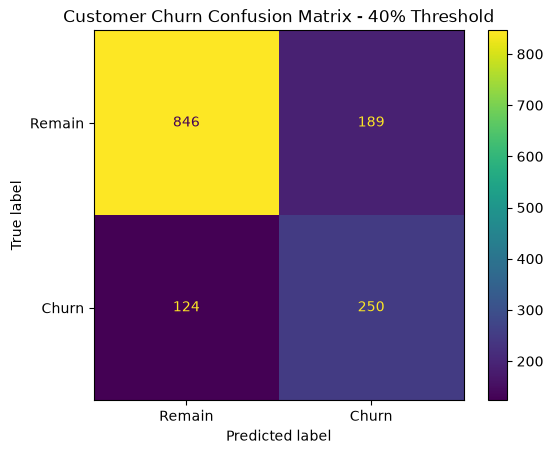

In [ ]:
# ==========================================
# Confusion Matrix - 40% Threshold
# ==========================================

cm_40 = confusion_matrix(
    y_test,
    y_pred_40
)

disp_40 = ConfusionMatrixDisplay(
    confusion_matrix=cm_40,
    display_labels=["Remain", "Churn"]
)

disp_40.plot()

plt.title(
    "Customer Churn Confusion Matrix - 40% Threshold"
)

plt.show()

In [ ]:
# ==========================================
# Logistic Regression Feature Importance
# ==========================================

feature_names = X_test.columns

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute importance
feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Importance
25,Contract_Two year,-1.328243,1.328243
1,tenure,-1.249330,1.249330
10,InternetService_Fiber optic,1.193660,1.193660
24,Contract_One year,-0.685633,0.685633
3,TotalCharges,0.519893,0.519893
7,PhoneService_Yes,-0.500163,0.500163
2,MonthlyCharges,-0.481375,0.481375
21,StreamingTV_Yes,0.381099,0.381099
28,PaymentMethod_Electronic check,0.380941,0.380941
23,StreamingMovies_Yes,0.380234,0.380234


In [ ]:
# ==========================================
# Features Increasing Churn Risk
# ==========================================

positive_features = feature_importance[
    feature_importance["Coefficient"] > 0
].head(10)

positive_features

,Feature,Coefficient,Importance
10,InternetService_Fiber optic,1.193660,1.193660
3,TotalCharges,0.519893,0.519893
21,StreamingTV_Yes,0.381099,0.381099
28,PaymentMethod_Electronic check,0.380941,0.380941
23,StreamingMovies_Yes,0.380234,0.380234
26,PaperlessBilling_Yes,0.370366,0.370366
9,MultipleLines_Yes,0.364331,0.364331
0,SeniorCitizen,0.145873,0.145873
29,PaymentMethod_Mailed check,0.068832,0.068832
17,DeviceProtection_Yes,0.037195,0.037195


In [ ]:
# ==========================================
# Features Decreasing Churn Risk
# ==========================================

negative_features = feature_importance[
    feature_importance["Coefficient"] < 0
].sort_values(
    "Coefficient"
).head(10)

negative_features

,Feature,Coefficient,Importance
25,Contract_Two year,-1.328243,1.328243
1,tenure,-1.249330,1.249330
24,Contract_One year,-0.685633,0.685633
7,PhoneService_Yes,-0.500163,0.500163
2,MonthlyCharges,-0.481375,0.481375
13,OnlineSecurity_Yes,-0.346818,0.346818
19,TechSupport_Yes,-0.295909,0.295909
8,MultipleLines_No phone service,-0.258240,0.258240
6,Dependents_Yes,-0.224993,0.224993
16,DeviceProtection_No internet service,-0.174682,0.174682


In [ ]:
# ==========================================
# Logistic Regression Odds Ratios
# ==========================================

feature_importance["Odds_Ratio"] = np.exp(
    feature_importance["Coefficient"]
)

odds_ratio_table = feature_importance[
    ["Feature", "Coefficient", "Odds_Ratio"]
].sort_values(
    "Odds_Ratio",
    ascending=False
)

odds_ratio_table.head(15)

,Feature,Coefficient,Odds_Ratio
10,InternetService_Fiber optic,1.193660,3.299133
3,TotalCharges,0.519893,1.681848
21,StreamingTV_Yes,0.381099,1.463893
28,PaymentMethod_Electronic check,0.380941,1.463662
23,StreamingMovies_Yes,0.380234,1.462626
26,PaperlessBilling_Yes,0.370366,1.448264
9,MultipleLines_Yes,0.364331,1.439550
0,SeniorCitizen,0.145873,1.157049
29,PaymentMethod_Mailed check,0.068832,1.071256
17,DeviceProtection_Yes,0.037195,1.037896


In [ ]:
odds_ratio_table.tail(10)

,Feature,Coefficient,Odds_Ratio
12,OnlineSecurity_No internet service,-0.174682,0.839724
6,Dependents_Yes,-0.224993,0.798522
8,MultipleLines_No phone service,-0.258240,0.772410
19,TechSupport_Yes,-0.295909,0.743855
13,OnlineSecurity_Yes,-0.346818,0.706934
2,MonthlyCharges,-0.481375,0.617933
7,PhoneService_Yes,-0.500163,0.606432
24,Contract_One year,-0.685633,0.503771
1,tenure,-1.249330,0.286697
25,Contract_Two year,-1.328243,0.264942


## Model Explainability

The Logistic Regression model provides interpretable coefficients that help identify
features associated with higher or lower customer churn risk.

### Features Associated with Higher Churn Risk

The strongest positive associations in the fitted model include:

- Fiber optic internet service
- Total charges
- Streaming TV
- Electronic check payment
- Streaming Movies
- Paperless billing
- Multiple lines

The strongest positive coefficient is associated with fiber optic internet service,
with an odds ratio of approximately 3.30.

### Features Associated with Lower Churn Risk

The strongest negative associations include:

- Two-year contract
- Customer tenure
- One-year contract
- Phone service
- Online security
- Technical support
- Dependents

The two-year contract feature has an odds ratio of approximately 0.265,
indicating a strong negative association with churn odds in the fitted model.

### Interpretation Note

Odds ratios describe associations learned by the Logistic Regression model and
should not be interpreted as evidence of causation.

For standardized numerical variables such as tenure, MonthlyCharges, and
TotalCharges, the odds ratio corresponds to a one-unit increase in the
standardized feature rather than necessarily one original unit of measurement.

In [ ]:
# ==========================================
# Customer-Level Churn Explanation
# ==========================================

# Select one customer from the test set
customer_index = 0

customer = X_test.iloc[customer_index]

# Get model coefficients
coefficients = model.coef_[0]

# Calculate contribution of each feature
contributions = customer * coefficients

# Create explanation table
explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Customer_Value": customer.values,
    "Coefficient": coefficients,
    "Contribution": contributions.values
})

# Sort by absolute contribution
explanation["Absolute_Contribution"] = (
    explanation["Contribution"].abs()
)

explanation = explanation.sort_values(
    "Absolute_Contribution",
    ascending=False
)

explanation.head(15)

,Feature,Customer_Value,Coefficient,Contribution,Absolute_Contribution
1,tenure,1.613701,-1.249330,-2.016045,2.016045
3,TotalCharges,2.730245,0.519893,1.419435,1.419435
25,Contract_Two year,1.000000,-1.328243,-1.328243,1.328243
10,InternetService_Fiber optic,1.000000,1.193660,1.193660,1.193660
2,MonthlyCharges,1.638143,-0.481375,-0.788561,0.788561
7,PhoneService_Yes,1.000000,-0.500163,-0.500163,0.500163
21,StreamingTV_Yes,1.000000,0.381099,0.381099,0.381099
23,StreamingMovies_Yes,1.000000,0.380234,0.380234,0.380234
26,PaperlessBilling_Yes,1.000000,0.370366,0.370366,0.370366
9,MultipleLines_Yes,1.000000,0.364331,0.364331,0.364331


In [ ]:
# ==========================================
# Customer Risk Factors
# ==========================================

risk_factors = explanation[
    explanation["Contribution"] > 0
].head(5)

print("TOP RISK FACTORS")
print(risk_factors[
    ["Feature", "Contribution"]
])

TOP RISK FACTORS
                        Feature  Contribution
3                  TotalCharges      1.419435
10  InternetService_Fiber optic      1.193660
21              StreamingTV_Yes      0.381099
23          StreamingMovies_Yes      0.380234
26         PaperlessBilling_Yes      0.370366


In [ ]:
# ==========================================
# Customer Protective Factors
# ==========================================

protective_factors = explanation[
    explanation["Contribution"] < 0
].sort_values(
    "Contribution"
).head(5)

print("TOP PROTECTIVE FACTORS")
print(protective_factors[
    ["Feature", "Contribution"]
])

TOP PROTECTIVE FACTORS
               Feature  Contribution
1               tenure     -2.016045
25   Contract_Two year     -1.328243
2       MonthlyCharges     -0.788561
7     PhoneService_Yes     -0.500163
13  OnlineSecurity_Yes     -0.346818


In [ ]:
# ==========================================
# Verify Customer-Level Explanation
# ==========================================

customer_probability = model.predict_proba(
    X_test.iloc[[customer_index]]
)[0][1]

customer_prediction = model.predict(
    X_test.iloc[[customer_index]]
)[0]

log_odds = model.intercept_[0] + contributions.sum()

calculated_probability = 1 / (
    1 + np.exp(-log_odds)
)

print("Model probability:", customer_probability)
print("Calculated probability:", calculated_probability)
print("Prediction:", customer_prediction)
print("Log-odds:", log_odds)

Model probability: 0.0456520707826071
Calculated probability: 0.0456520707826071
Prediction: 0
Log-odds: -3.039979342465731


In [ ]:
# ==========================================
# Human-Readable Customer Explanation
# ==========================================

top_risk = explanation[
    explanation["Contribution"] > 0
].head(5)

top_protective = explanation[
    explanation["Contribution"] < 0
].sort_values(
    "Contribution"
).head(5)

print("=" * 50)
print("CUSTOMER CHURN EXPLANATION")
print("=" * 50)

print("\nTOP RISK FACTORS")

for _, row in top_risk.iterrows():
    print(
        f"• {row['Feature']}: "
        f"+{row['Contribution']:.3f}"
    )

print("\nTOP PROTECTIVE FACTORS")

for _, row in top_protective.iterrows():
    print(
        f"• {row['Feature']}: "
        f"{row['Contribution']:.3f}"
    )

CUSTOMER CHURN EXPLANATION

TOP RISK FACTORS
• TotalCharges: +1.419
• InternetService_Fiber optic: +1.194
• StreamingTV_Yes: +0.381
• StreamingMovies_Yes: +0.380
• PaperlessBilling_Yes: +0.370

TOP PROTECTIVE FACTORS
• tenure: -2.016
• Contract_Two year: -1.328
• MonthlyCharges: -0.789
• PhoneService_Yes: -0.500
• OnlineSecurity_Yes: -0.347
